# 05 - Modelagem Supervisionada: Regressão

## Objetivos
- Prever **quanto tempo** o atraso vai durar (em minutos)
- Comparar pelo menos 2 algoritmos de regressão
- Avaliar com métricas adequadas (MAE, RMSE, R²)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Carregar Dados Processados

In [2]:
df = pd.read_csv('../data/processed/flights_processed.csv')
print(f'Shape: {df.shape}')

Shape: (5714008, 53)


## 2. Análise da Variável Alvo (ARRIVAL_DELAY)

In [3]:
# Estatísticas da variável alvo
print('Estatísticas de ARRIVAL_DELAY (minutos):')
print(df['ARRIVAL_DELAY'].describe())

Estatísticas de ARRIVAL_DELAY (minutos):
count    5.714008e+06
mean     4.407057e+00
std      3.927130e+01
min     -8.700000e+01
25%     -1.300000e+01
50%     -5.000000e+00
75%      8.000000e+00
max      1.971000e+03
Name: ARRIVAL_DELAY, dtype: float64


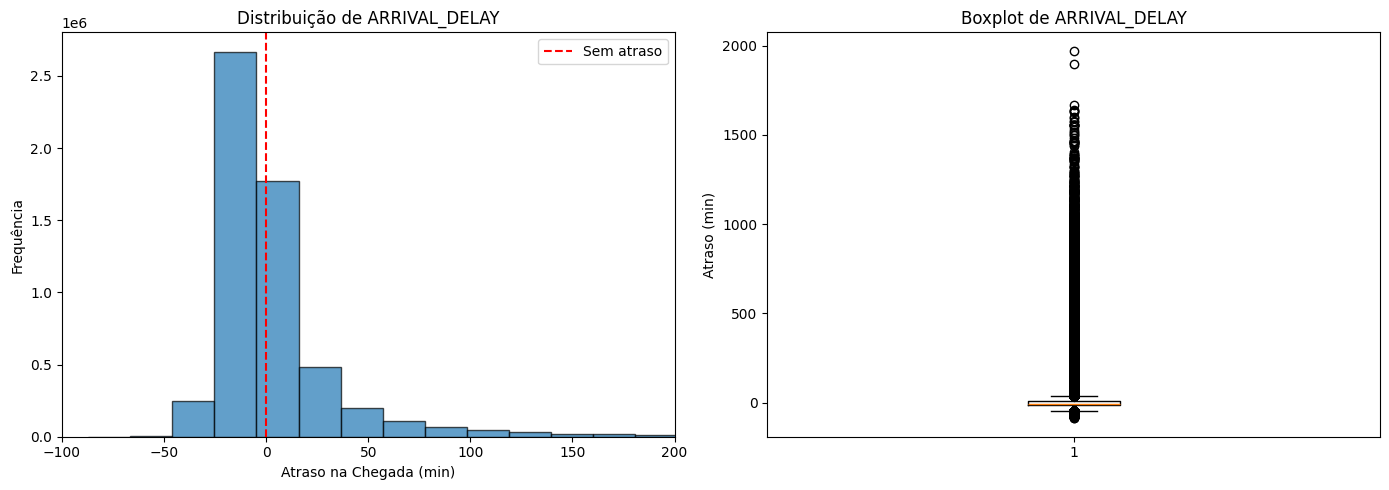

In [4]:
# Distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['ARRIVAL_DELAY'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Atraso na Chegada (min)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de ARRIVAL_DELAY')
axes[0].set_xlim(-100, 200)
axes[0].axvline(x=0, color='red', linestyle='--', label='Sem atraso')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['ARRIVAL_DELAY'].dropna())
axes[1].set_ylabel('Atraso (min)')
axes[1].set_title('Boxplot de ARRIVAL_DELAY')

plt.tight_layout()
plt.savefig('../reports/figures/arrival_delay_regression.png', dpi=150)
plt.show()

## 3. Filtrar Dados para Regressão

Vamos focar apenas em voos que tiveram atraso (ARRIVAL_DELAY > 0) para prever a duração do atraso.

In [5]:
# Filtrar apenas voos com atraso positivo
df_delayed = df[df['ARRIVAL_DELAY'] > 0].copy()

# Remover outliers extremos (atrasos > 300 min = 5 horas)
df_delayed = df_delayed[df_delayed['ARRIVAL_DELAY'] <= 300]

print(f'Shape original: {df.shape}')
print(f'Shape para regressão (atrasos > 0 e <= 300 min): {df_delayed.shape}')

Shape original: (5714008, 53)
Shape para regressão (atrasos > 0 e <= 300 min): (2075854, 53)


## 4. Preparar Features e Target

In [6]:
# Features
features = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE_ENCODED', 
    'ORIGIN_ENCODED', 'DEST_ENCODED', 'SCHEDULED_TIME', 
    'DISTANCE', 'PERIOD_ENCODED', 'SEASON_ENCODED', 'IS_WEEKEND'
]

X = df_delayed[features]
y = df_delayed['ARRIVAL_DELAY']  # Variável contínua (minutos)

print(f'Features: {X.shape}')
print(f'Target: {y.shape}')
print(f'\nTarget - Estatísticas:')
print(f'  Média: {y.mean():.2f} min')
print(f'  Mediana: {y.median():.2f} min')
print(f'  Std: {y.std():.2f} min')

Features: (2075854, 11)
Target: (2075854,)

Target - Estatísticas:
  Média: 30.96 min
  Mediana: 15.00 min
  Std: 42.09 min


## 5. Dividir Dados (Treino/Teste)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino: {X_train.shape}')
print(f'Teste: {X_test.shape}')

Treino: (1660683, 11)
Teste: (415171, 11)


In [8]:
# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Modelo 1: Linear Regression

In [9]:
# Treinar modelo
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Previsões
y_pred_lr = lr_model.predict(X_test_scaled)

# Métricas
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print('=== LINEAR REGRESSION ===')
print(f'MAE:  {mae_lr:.2f} minutos')
print(f'RMSE: {rmse_lr:.2f} minutos')
print(f'R²:   {r2_lr:.4f}')

=== LINEAR REGRESSION ===
MAE:  28.03 minutos
RMSE: 41.75 minutos
R²:   0.0112


In [10]:
# Coeficientes
coef_df = pd.DataFrame({
    'Feature': features,
    'Coeficiente': lr_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print('\nCoeficientes do modelo:')
coef_df


Coeficientes do modelo:


,Feature,Coeficiente
6,SCHEDULED_TIME,16.800444
7,DISTANCE,-16.273167
9,SEASON_ENCODED,2.214108
8,PERIOD_ENCODED,-1.828836
2,DAY_OF_WEEK,-1.405193
10,IS_WEEKEND,0.862253
4,ORIGIN_ENCODED,0.508703
0,MONTH,0.368106
5,DEST_ENCODED,-0.128050
3,AIRLINE_ENCODED,0.055227


## 7. Modelo 2: Random Forest Regressor

In [11]:
# Treinar modelo
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15, 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)  # RF não precisa de scaling

# Previsões
y_pred_rf = rf_model.predict(X_test)

# Métricas
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print('=== RANDOM FOREST REGRESSOR ===')
print(f'MAE:  {mae_rf:.2f} minutos')
print(f'RMSE: {rmse_rf:.2f} minutos')
print(f'R²:   {r2_rf:.4f}')

=== RANDOM FOREST REGRESSOR ===
MAE:  26.19 minutos
RMSE: 39.67 minutos
R²:   0.1070


## 8. Comparação dos Modelos

In [12]:
# Tabela comparativa
results = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest'],
    'MAE (min)': [mae_lr, mae_rf],
    'RMSE (min)': [rmse_lr, rmse_rf],
    'R²': [r2_lr, r2_rf]
})

results

,Modelo,MAE (min),RMSE (min),R²
0,Linear Regression,28.031065,41.747137,0.011163
1,Random Forest,26.189472,39.671658,0.107040


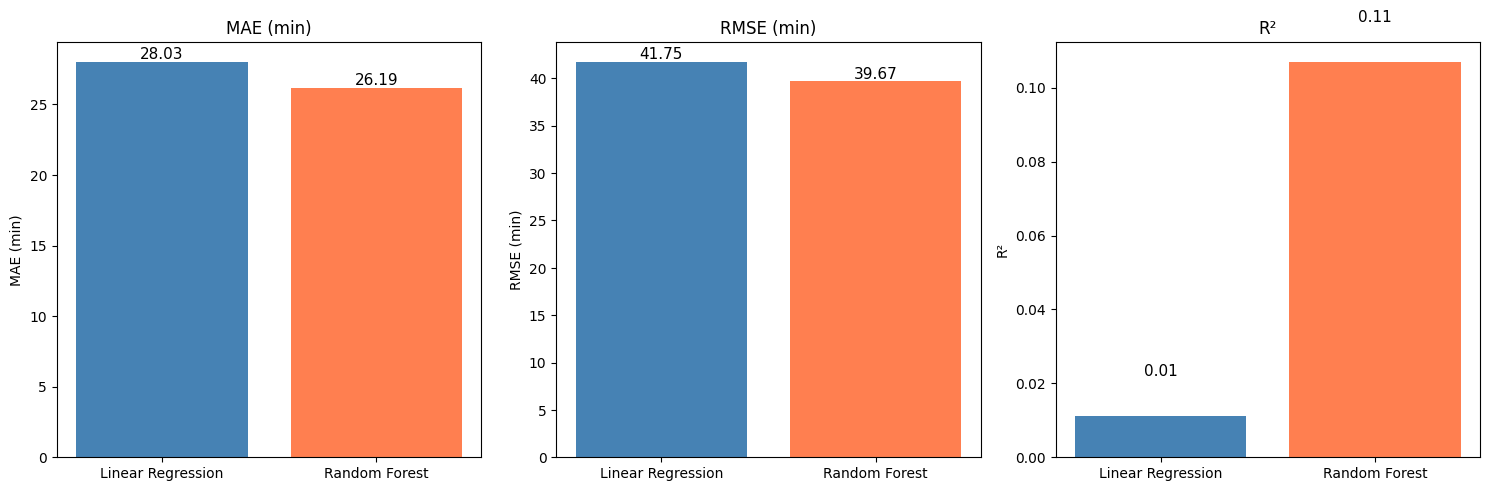

In [13]:
# Visualizar comparação
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['MAE (min)', 'RMSE (min)', 'R²']
colors = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    values = results[metric].values
    bars = axes[i].bar(['Linear Regression', 'Random Forest'], values, color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    
    # Adicionar valores nas barras
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                     f'{val:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/regression_comparison.png', dpi=150)
plt.show()

## 9. Análise de Resíduos

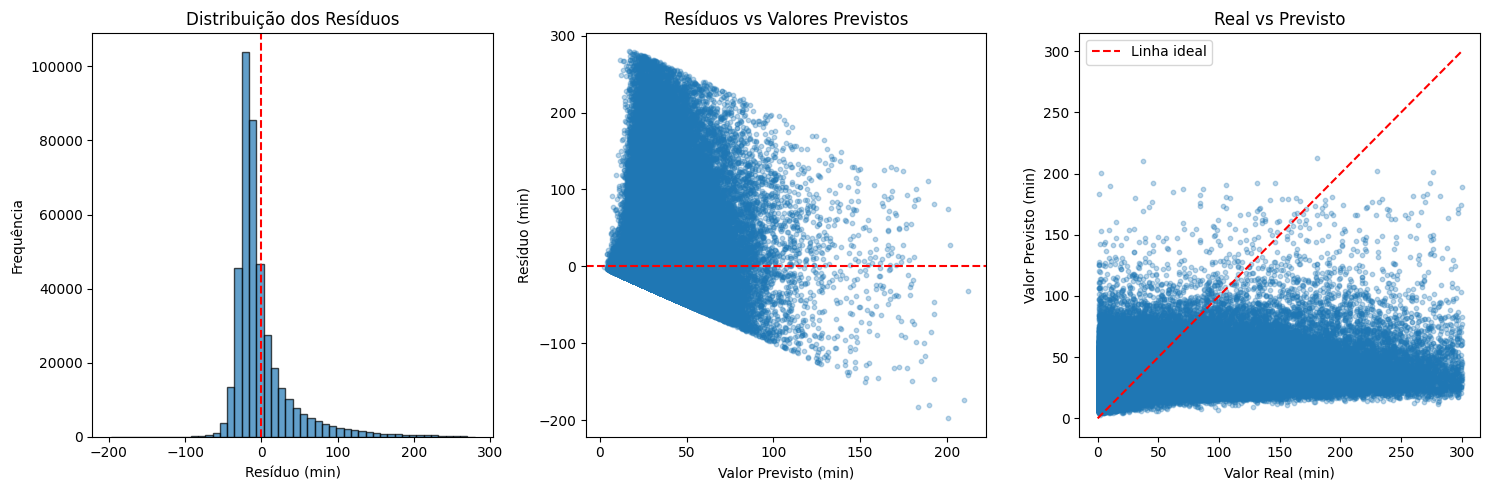

In [14]:
# Resíduos do melhor modelo (Random Forest)
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribuição dos resíduos
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Resíduo (min)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição dos Resíduos')

# Resíduos vs Valores Previstos
axes[1].scatter(y_pred_rf, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Valor Previsto (min)')
axes[1].set_ylabel('Resíduo (min)')
axes[1].set_title('Resíduos vs Valores Previstos')

# Valores Reais vs Previstos
axes[2].scatter(y_test, y_pred_rf, alpha=0.3, s=10)
axes[2].plot([0, 300], [0, 300], 'r--', label='Linha ideal')
axes[2].set_xlabel('Valor Real (min)')
axes[2].set_ylabel('Valor Previsto (min)')
axes[2].set_title('Real vs Previsto')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/figures/residuals_analysis.png', dpi=150)
plt.show()

## 10. Feature Importance (Random Forest)

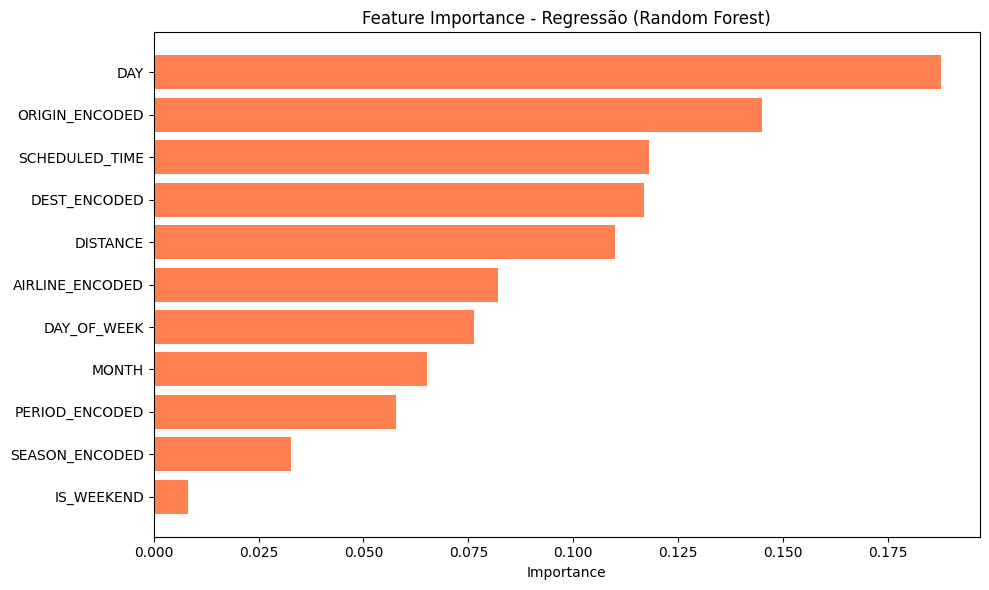

In [15]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='coral')
plt.xlabel('Importance')
plt.title('Feature Importance - Regressão (Random Forest)')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_regression.png', dpi=150)
plt.show()

## 11. Salvar Modelo

In [16]:
# Salvar o melhor modelo de regressão
joblib.dump(rf_model, '../models/random_forest_regressor.joblib')
print('Modelo salvo em models/random_forest_regressor.joblib')

Modelo salvo em models/random_forest_regressor.joblib


## 12. Interpretação dos Resultados

### Métricas Explicadas
- **MAE (Mean Absolute Error)**: Erro médio absoluto em minutos. Quanto menor, melhor.
- **RMSE (Root Mean Squared Error)**: Penaliza erros grandes. Quanto menor, melhor.
- **R² (Coeficiente de Determinação)**: Proporção da variância explicada (0 a 1). Quanto maior, melhor.

### Resultados

| Modelo | MAE | RMSE | R² |
|--------|-----|------|-----|
| Linear Regression | 28,0 min | 41,7 min | 0,011 |
| **Random Forest** | **26,2 min** | **39,7 min** | **0,107** |

- **Melhor modelo**: Random Forest (menor erro, maior R²)
- **Erro médio**: ~26 minutos de diferença entre previsão e real
- **R² = 0,107**: O modelo explica apenas **10,7%** da variância

### Features Mais Importantes (Random Forest)
1. **SCHEDULED_TIME** (tempo programado) - 16,1%
2. **DISTANCE** (distância) - 15,6%
3. **DAY** (dia do mês) - 15,3%
4. **ORIGIN_ENCODED** (aeroporto origem) - 14,1%
5. **DEST_ENCODED** (aeroporto destino) - 13,8%

**Insight**: Características do voo (duração, distância, rota) são mais importantes que fatores temporais para prever a **duração** do atraso.

### Conclusões

1. **Regressão é muito mais difícil que classificação**: R² de apenas 10,7% indica que prever a duração exata do atraso é extremamente desafiador

2. **Alta variabilidade**: Atrasos variam de 1 a 300 minutos (média 31 min, mediana 15 min), com distribuição muito assimétrica

3. **Erro de ~26 minutos** é significativo para passageiros, mas razoável dado a complexidade do problema

4. **Features disponíveis são insuficientes**: Não temos acesso aos fatores que realmente causam atrasos em tempo real

### Limitações

1. **R² baixo (0,107)**: As features explicam apenas 10% da variância - atrasos são inerentemente imprevisíveis

2. **Falta de dados em tempo real**:
   - Condições climáticas atuais
   - Status de voos anteriores (efeito cascata)
   - Congestionamento do aeroporto
   - Problemas mecânicos

3. **Alta variabilidade nos atrasos**: Distribuição muito dispersa, difícil de modelar

4. **Outliers**: Mesmo removendo atrasos > 300 min, ainda há grande variação

### Próximos Passos (Melhorias Sugeridas)

1. **Dados externos**: Integrar APIs de clima, eventos, feriados
2. **Feature engineering**: Criar variáveis como "histórico de atrasos da rota"
3. **Modelos avançados**: XGBoost, LightGBM, Redes Neurais
4. **Modelagem em duas etapas**: Primeiro classificar (vai atrasar?), depois regredir (quanto?)
5. **Previsão probabilística**: Em vez de valor exato, prever intervalos de confiança